In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("final_ml_data.csv")
df.head()

,subject_id,text,gender,dod,mortality,dischtime,race,marital_status,number_of_readmissions,age_group,stroke_class,admittime_date,blood_pressure,entities
0,10081794,Name: ___ Unit No: ___ Admiss...,F,NaN,0,28/10/2161 15:15,WHITE,DIVORCED,1,65–74,History of TIA,21/10/2161,normal,"['mL: DOSAGE', '50 mcg/: DOSAGE', '25 mg: DOSA..."
1,10083062,Name: ___ Unit No: ___...,F,NaN,0,03/11/2171 19:13,WHITE,SINGLE,0,65–74,History of TIA,31/10/2171,120/50,"['Salmeterol: MEDICATION', '250-50 mcg/Dose: D..."
2,10085941,Name: ___ Unit No: ___ ...,F,18/04/2142,1,21/03/2142 13:30,BLACK/AFRICAN AMERICAN,SINGLE,0,75–84,Hemorrhagic stroke,17/03/2142,125/80,"['100: DOSAGE', 'DAILY: DOSAGE', '10 mg: DOSAG..."
3,10086861,Name: ___ Unit No: __...,F,NaN,0,21/11/2131 18:20,WHITE,MARRIED,0,65–74,Ischemic stroke,20/11/2131,161/64,"['aspirin: MEDICATION', '40 mg daily: DOSAGE',..."
4,10087948,Name: ___ Unit No: ___ ...,M,14/05/2115,1,25/04/2115 14:30,WHITE,MARRIED,0,75–84,History of TIA,21/04/2115,140/78,"['8: DOSAGE', '2 times a day: DOSAGE', '5 mg: ..."


In [ ]:
len(df)

1513

In [ ]:
df.columns

Index(['subject_id', 'text', 'gender', 'dod', 'mortality', 'dischtime', 'race',
       'marital_status', 'number_of_readmissions', 'age_group', 'stroke_class',
       'admittime_date', 'blood_pressure', 'entities'],
      dtype='object')

### Summary Statistics and Univariate Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   subject_id              1513 non-null   int64 
 1   text                    1513 non-null   object
 2   gender                  1513 non-null   object
 3   dod                     556 non-null    object
 4   mortality               1513 non-null   int64 
 5   dischtime               1513 non-null   object
 6   race                    1513 non-null   object
 7   marital_status          1513 non-null   object
 8   number_of_readmissions  1513 non-null   int64 
 9   age_group               1513 non-null   object
 10  stroke_class            1513 non-null   object
 11  admittime_date          1513 non-null   object
 12  blood_pressure          1513 non-null   object
 13  entities                1513 non-null   object
dtypes: int64(3), object(11)
memory usage: 165.6+ KB


In [ ]:
df["age_group"].unique()

array(['65–74', '75–84', '85+', '45–64', '18–44'], dtype=object)

In [ ]:
df["gender"].value_counts()

,count
gender,
F,759
M,754


In [ ]:
df["race"].value_counts()

,count
race,
WHITE,1030
UNKNOWN,130
BLACK/AFRICAN AMERICAN,116
OTHER,42
WHITE - RUSSIAN,22
ASIAN,20
WHITE - OTHER EUROPEAN,16
BLACK/CARIBBEAN ISLAND,15
HISPANIC/LATINO - PUERTO RICAN,14


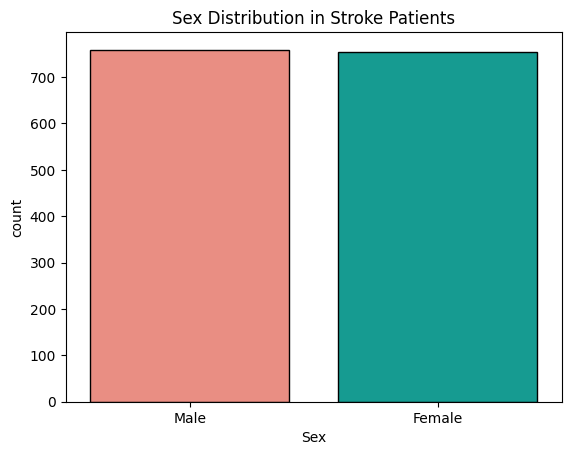

In [ ]:
sns.countplot(x="gender", data=df, edgecolor="black", palette={"M": "#00B1A4", "F": "salmon"})
plt.title("Sex Distribution in Stroke Patients")
plt.xticks([00,1], ["Male", "Female"])
plt.xlabel("Sex")
plt.savefig("sex_distribution.png", dpi=500)
plt.show()

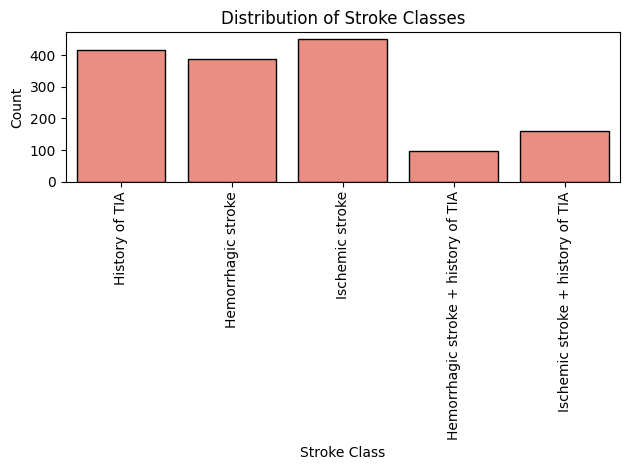

In [ ]:
sns.countplot(x="stroke_class", data=df, edgecolor="black", color="salmon")
plt.title("Distribution of Stroke Classes")
plt.xlabel("Stroke Class")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("class_count.png", dpi=500, bbox_inches='tight')
plt.show()

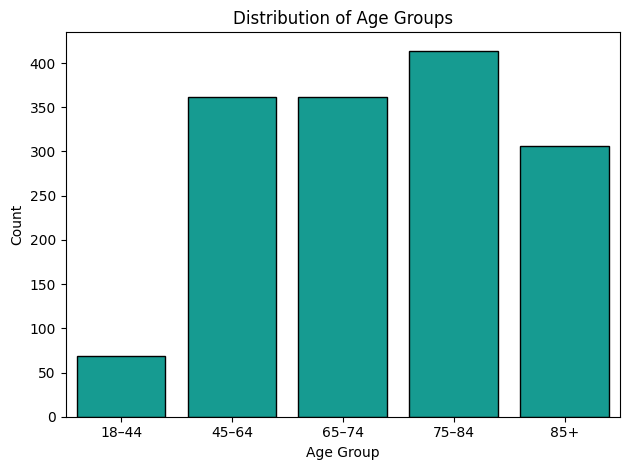

In [ ]:
age_order = ["18–44","45–64","65–74","75–84","85+"]
sns.countplot(x="age_group", data=df, edgecolor="black", color="#00B1A4", order=age_order)
plt.title("Distribution of Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks()
plt.tight_layout()
plt.savefig("ageGroup_count.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
df["race"] = df["race"].str.upper()
df["race"] = df["race"].apply(lambda x: "WHITE" if "WHITE" in x else "NON-WHITE")
df["race"].value_counts()

,count
race,
WHITE,1070
NON-WHITE,443


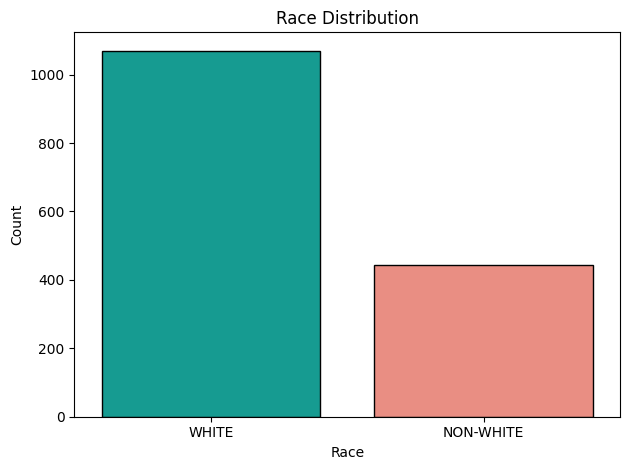

In [ ]:
sns.countplot(x="race", data=df, edgecolor="black", palette={"WHITE": "#00B1A4", "NON-WHITE": "salmon"})
plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks()
plt.tight_layout()
plt.savefig("race_count.png", dpi=500, bbox_inches='tight')
plt.show()

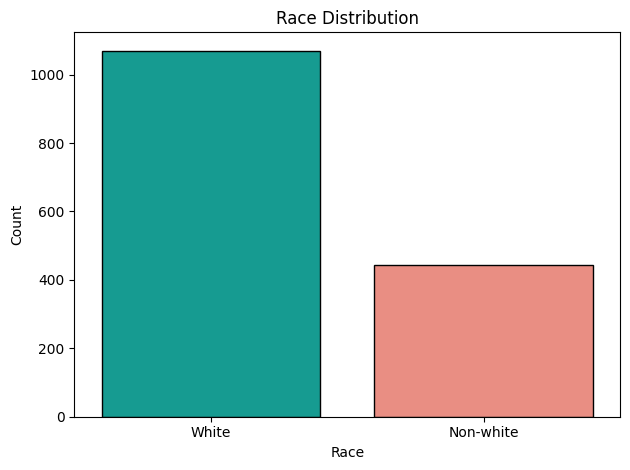

In [ ]:
ax = sns.countplot(
    x="race",
    data=df,
    edgecolor="black",
    palette={"WHITE": "#00B1A4", "NON-WHITE": "salmon"}
)

ax.set_xticklabels(["White", "Non-white"])

plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("race_count.png", dpi=500, bbox_inches="tight")
plt.show()

### Create Visualizations

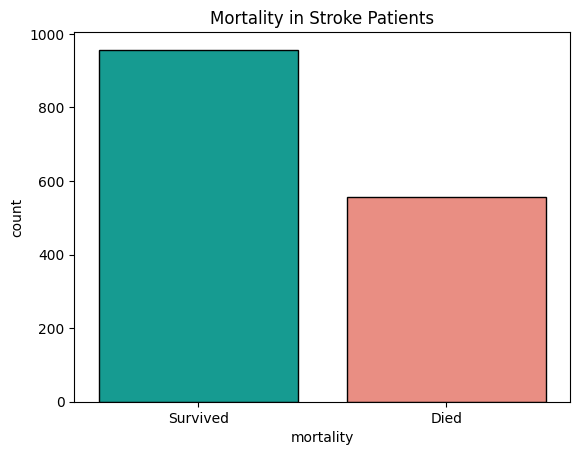

In [ ]:
# Target variable
sns.countplot(x="mortality", data=df, edgecolor="black", palette={"0": "#00B1A4", "1": "salmon"})
plt.title("Mortality in Stroke Patients")
plt.xticks([0,1], ["Survived", "Died"])
plt.savefig("mortality_distribution.png", dpi=500)
plt.show()

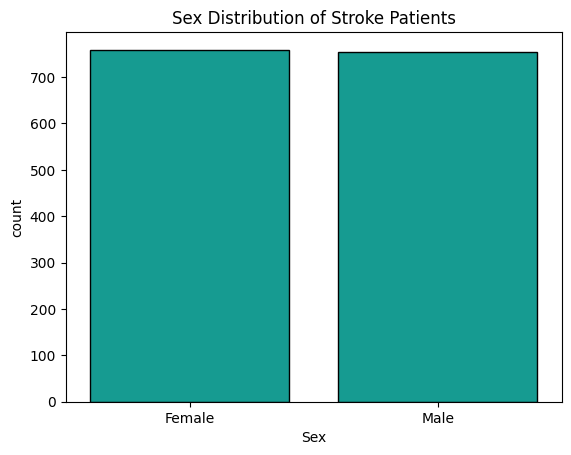

In [ ]:
# Sex distribution
sns.countplot(x="gender", data=df, edgecolor="black", color="#00B1A4")
plt.xlabel("Sex")
plt.title("Sex Distribution of Stroke Patients")
plt.xticks(["M","F"], ["Male", "Female"])
plt.savefig("sex_distribution_b.png", dpi=500)
plt.show()

In [ ]:
 # Death distribution by age group
age_order = ["18–44","45–64","65–74","75–84","85+"]
ratio_df = (df.groupby("age_group", observed=False)["mortality"].value_counts().unstack(fill_value=0).reset_index())
ratio_df.head()

mortality,age_group,0,1
0,18–44,62,7
1,45–64,292,70
2,65–74,236,126
3,75–84,232,182
4,85+,135,171


In [ ]:
ratio_df.columns

Index(['age_group', 0, 1], dtype='object', name='mortality')

In [ ]:
ratio_df.columns = ["age_group", "Alive", "Dead"]

In [ ]:
ratio_df["living_to_dead_ratio"] = ratio_df["Alive"] / ratio_df["Dead"]

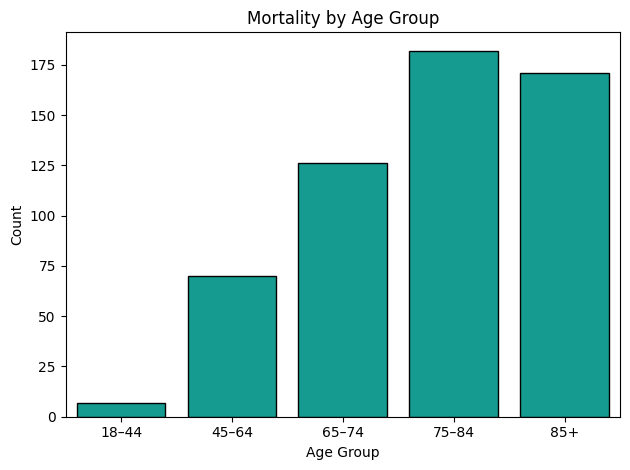

In [ ]:
sns.barplot(x="age_group", y="Dead", data=ratio_df, order=age_order, edgecolor="black", color="#00B1A4")
plt.title("Mortality by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks()
plt.tight_layout()
plt.savefig("mortality_by_age_group.png", dpi=500, bbox_inches='tight')
plt.show()

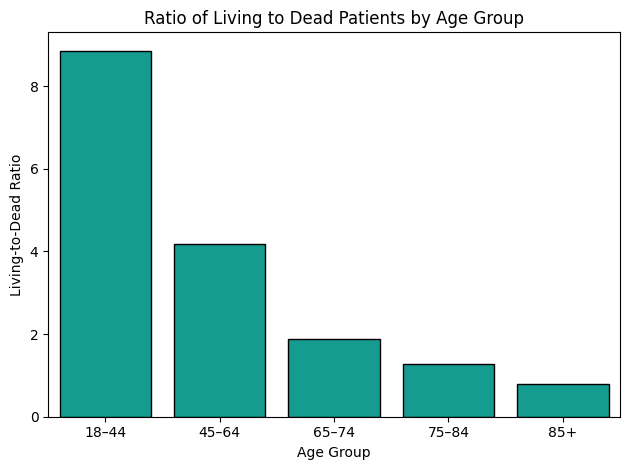

In [ ]:
sns.barplot(x="age_group", y="living_to_dead_ratio", data=ratio_df, order=age_order, edgecolor="black", color="#00B1A4")
plt.title("Ratio of Living to Dead Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Living-to-Dead Ratio")
plt.xticks()
plt.tight_layout()
plt.savefig("mortality_by_age_group_b.png", dpi=500, bbox_inches='tight')
plt.show()

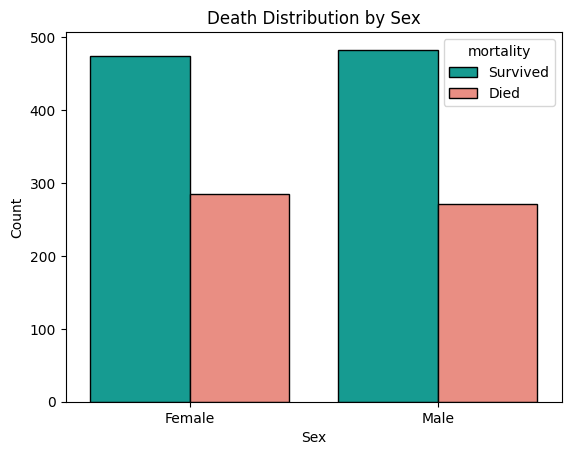

In [ ]:
# Death distribution by sex
sns.countplot(x="gender", hue="mortality", data=df, edgecolor="black", palette={0:"#00B1A4", 1: "salmon"})
plt.title("Death Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="mortality", labels=["Survived", "Died"])
plt.xticks(["M","F"], ["Male", "Female"])
plt.savefig("sex_death_distribution.png", dpi=500)
plt.show()

In [ ]:
df.columns

Index(['subject_id', 'text', 'gender', 'dod', 'mortality', 'dischtime', 'race',
       'marital_status', 'number_of_readmissions', 'age_group', 'stroke_class',
       'admittime_date', 'blood_pressure', 'entities'],
      dtype='object')

In [ ]:
# Prevalent icd code in dead patients
df["marital_status"].unique()

array(['DIVORCED', 'SINGLE', 'MARRIED', 'WIDOWED'], dtype=object)

In [ ]:
# Encode marital status
marital_status_mapping = {"MARRIED": "High", "SINGLE": "Medium", "DIVORCED": "Medium", "WIDOWED": "Low"}
df["care_level"] = df["marital_status"].map(marital_status_mapping)

In [ ]:
# Death distribution by care level
care_order = ["Medium","High","Low"]
ratio_care = (df.groupby("care_level", observed=False)["mortality"].value_counts().unstack(fill_value=0).reset_index())
ratio_care.head()

mortality,care_level,0,1
0,High,493,282
1,Low,177,152
2,Medium,287,122


In [ ]:
ratio_care.columns = ["Care Level", "Alive", "Dead"]

In [ ]:
ratio_care["living_to_dead_ratio"] = ratio_care["Alive"] / ratio_care["Dead"]

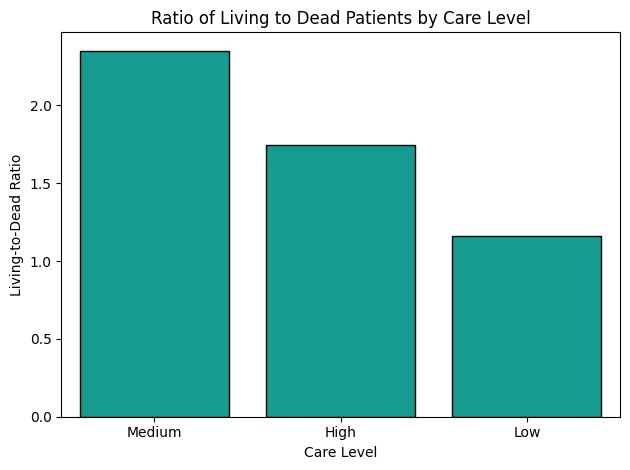

In [ ]:
sns.barplot(x="Care Level", y="living_to_dead_ratio", data=ratio_care, order=care_order, edgecolor="black", color="#00B1A4")
plt.title("Ratio of Living to Dead Patients by Care Level")
plt.xlabel("Care Level")
plt.ylabel("Living-to-Dead Ratio")
plt.xticks()
plt.tight_layout()
plt.savefig("care_ratio_death.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
df["stroke_class"].unique()

array(['History of TIA', 'Hemorrhagic stroke', 'Ischemic stroke',
       'Hemorrhagic stroke + history of TIA',
       'Ischemic stroke + history of TIA'], dtype=object)

In [ ]:
# Death distribution by stroke class
care_order = ["History of TIA", "Ischemic stroke","Hemorrhagic stroke",
              "Ischemic stroke + history of TIA","Hemorrhagic stroke + history of TIA"]
ratio_class = (df.groupby("stroke_class", observed=False)["mortality"].value_counts().unstack(fill_value=0).reset_index())
ratio_class.head()

mortality,stroke_class,0,1
0,Hemorrhagic stroke,238,151
1,Hemorrhagic stroke + history of TIA,49,47
2,History of TIA,293,124
3,Ischemic stroke,288,162
4,Ischemic stroke + history of TIA,89,72


In [ ]:
ratio_class.columns = ["Stroke Class", "Alive", "Dead"]

In [ ]:
ratio_class["living_to_dead_ratio"] = ratio_class["Alive"] / ratio_class["Dead"]

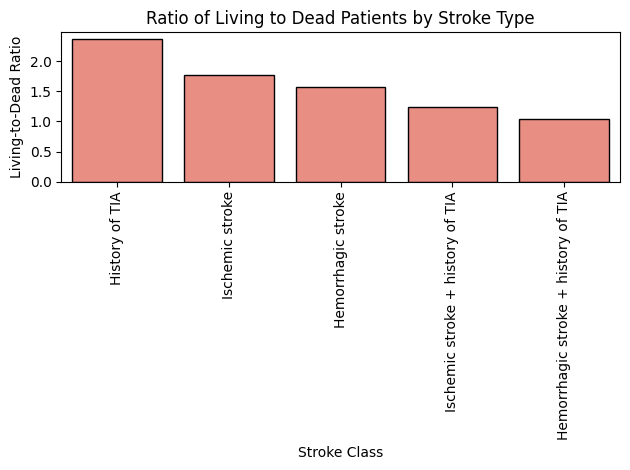

In [ ]:
sns.barplot(x="Stroke Class", y="living_to_dead_ratio", data=ratio_class,  color="salmon", order=care_order, edgecolor="black")
plt.title("Ratio of Living to Dead Patients by Stroke Type")
plt.xlabel("Stroke Class")
plt.ylabel("Living-to-Dead Ratio")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("class_ratio_death.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
# Stroke Classes
dead_patients = df[df["mortality"] == 1]
top_icd_codes = (dead_patients["stroke_class"].value_counts().head(10))

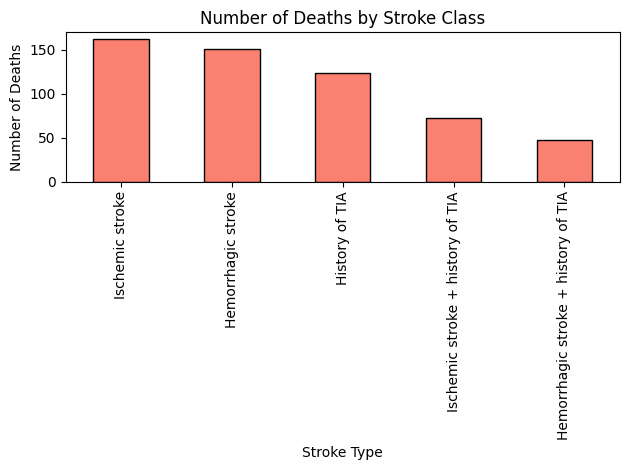

In [ ]:
top_icd_codes.plot(kind="bar", edgecolor="black", color="salmon")
plt.title("Number of Deaths by Stroke Class")
plt.xlabel("Stroke Type")
plt.ylabel("Number of Deaths")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("stroke_type_death_toll.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
# Death distribution over time
df_dead = df[df["dod"].notna()].copy()
df_dead["admitdate"] = df_dead["admittime_date"].str.split().str[0]
df_dead["admitdate"] = pd.to_datetime(df_dead["admitdate"], errors="coerce")
df_dead["dod"] = pd.to_datetime(df_dead["dod"], errors="coerce")

In [ ]:
df_dead["days_to_death"] = (df_dead["dod"] - df_dead["admitdate"]).dt.days
df_dead = df_dead[df_dead["days_to_death"] >= 0]
len(df_dead)

556

In [ ]:
df_first90 = df_dead[df_dead['days_to_death'] <= 90]
len(df_first90)

415

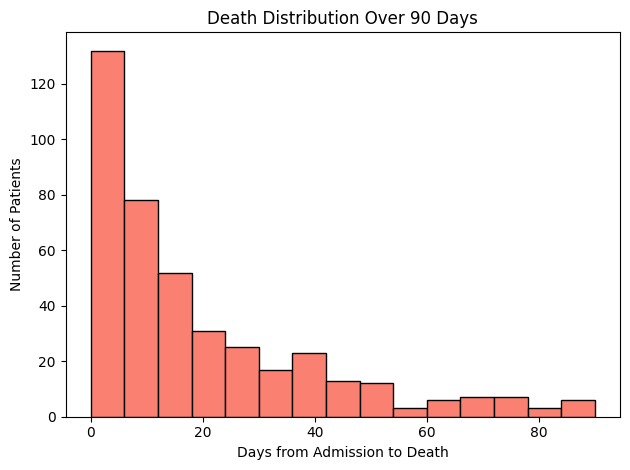

In [ ]:
plt.hist(df_first90["days_to_death"], bins=15, color="salmon", edgecolor="black")
plt.title("Death Distribution Over 90 Days")
plt.xlabel("Days from Admission to Death")
plt.ylabel("Number of Patients")
#plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.savefig("dist_death.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
df_within_one_day = df_first90[df_first90["days_to_death"] <= 1]
top_class_oneday = df_within_one_day["stroke_class"].value_counts()
print("Stroke Classes among patients who died within one day:")
print(top_class_oneday)

Stroke Classes among patients who died within one day:
stroke_class
Hemorrhagic stroke                     21
Ischemic stroke                        10
History of TIA                          7
Hemorrhagic stroke + history of TIA     4
Ischemic stroke + history of TIA        3
Name: count, dtype: int64


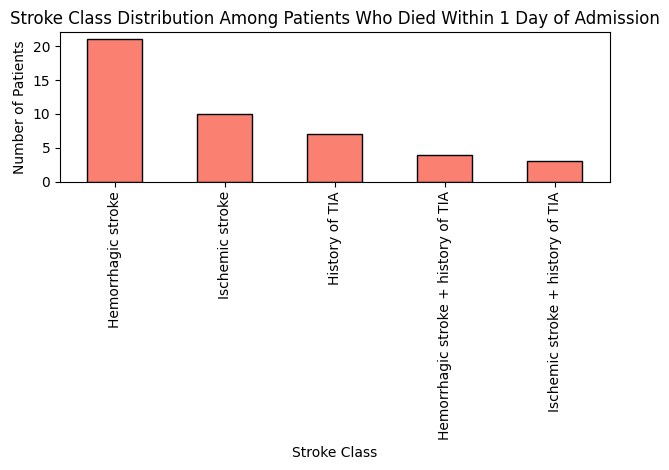

In [ ]:
top_class_oneday.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Stroke Class Distribution Among Patients Who Died Within 1 Day of Admission")
plt.xlabel("Stroke Class")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("stroke_type_dead_one.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
age_ratios_day1 = {"85+": [119,2721], "75-84":[105,4009], "65-74":[93,3522], "45-64":[94,3782], "18-44":[14,801]}
df_age = pd.DataFrame.from_dict(age_ratios_day1, orient='index', columns=['dead', 'alive']).reset_index()
df_age.columns = ['age_group', 'dead', 'alive']
df_age.head()

,age_group,dead,alive
0,85+,119,2721
1,75-84,105,4009
2,65-74,93,3522
3,45-64,94,3782
4,18-44,14,801


In [ ]:
df_age["living_to_dead_ratio"] = df_age["alive"] / df_age["dead"]

In [ ]:
order_age2 = ["18-44", "45-64", "65-74", "75-84", "85+"]

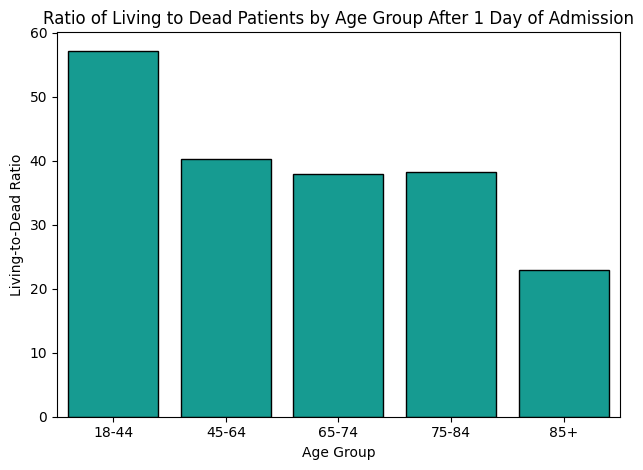

In [ ]:
sns.barplot(x="age_group", y="living_to_dead_ratio", data=df_age, order= order_age2, edgecolor="black", color="#00B1A4")
plt.title("Ratio of Living to Dead Patients by Age Group After 1 Day of Admission")
plt.xlabel("Age Group")
plt.ylabel("Living-to-Dead Ratio")
plt.xticks()
plt.tight_layout()
plt.savefig("age_death_ratio.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
# Blood Pressure
def classify_bp(value):
    # Handle nulls safely
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Explicit label handling
    if value in ["normal"]:
        return "normal"
    if value in ["low", "high", "abnormal"]:
        return "abnormal"

    # Numeric BP (e.g. "120/80")
    try:
        systolic, diastolic = map(int, value.split("/"))

        if 91 <= systolic <= 129 and 61 <= diastolic <= 84:
            return "normal"
        else:
            return "abnormal"

    except Exception:
        return "abnormal"

In [ ]:
df["blood_pressure"] = df["blood_pressure"].apply(classify_bp)

In [ ]:
dead_patients = df[df["mortality"] == 1]
bp_mortality = dead_patients["blood_pressure"].value_counts()

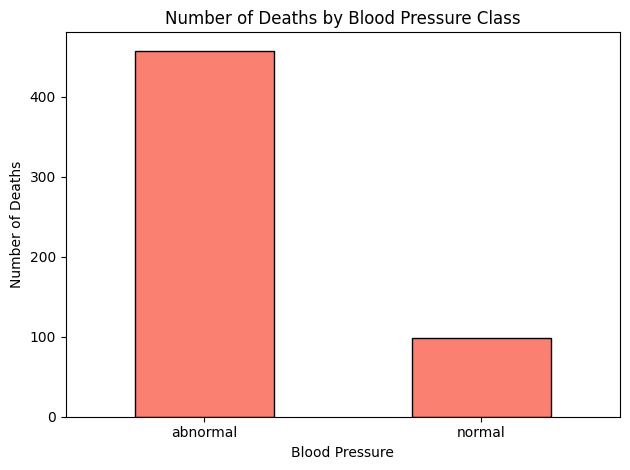

In [ ]:
bp_mortality.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Number of Deaths by Blood Pressure Class")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of Deaths")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("blood_pressure_death_toll.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
df["number_of_readmissions"].max()

31

In [ ]:
marital_status_mapping = {1: "Dead", 0: "Alive"}
df["mortality_coded"] = df["mortality"].map(marital_status_mapping)

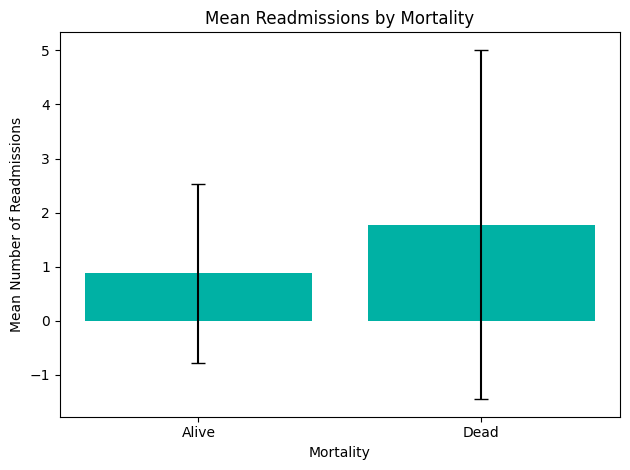

In [ ]:
# Number of readmissions
grouped = df.groupby("mortality_coded")["number_of_readmissions"]
means = grouped.mean()
stds = grouped.std()
# Bar chart
plt.figure()
plt.bar(means.index, means.values, yerr=stds.values, capsize=5, color="#00B1A4")
plt.xlabel("Mortality")
plt.ylabel("Mean Number of Readmissions")
plt.title("Mean Readmissions by Mortality")
plt.tight_layout()
plt.show()

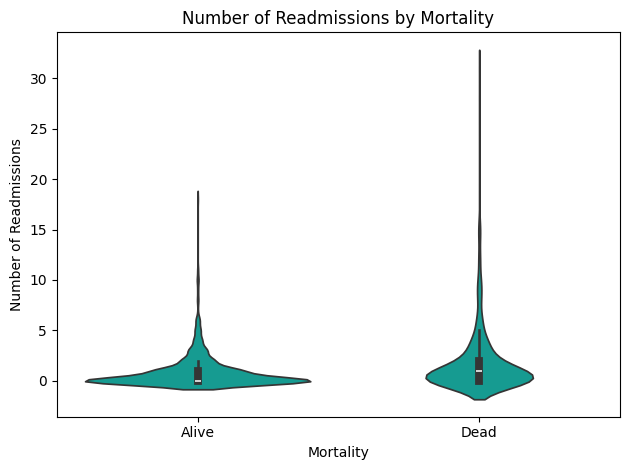

In [ ]:
sns.violinplot(x ="mortality_coded", y ="number_of_readmissions", data = df, color="#00B1A4")
plt.title("Number of Readmissions by Mortality")
plt.xlabel("Mortality")
plt.ylabel("Number of Readmissions")
plt.tight_layout()
plt.savefig("readmissions_mortality_vp.png", dpi=500, bbox_inches='tight')
plt.show()

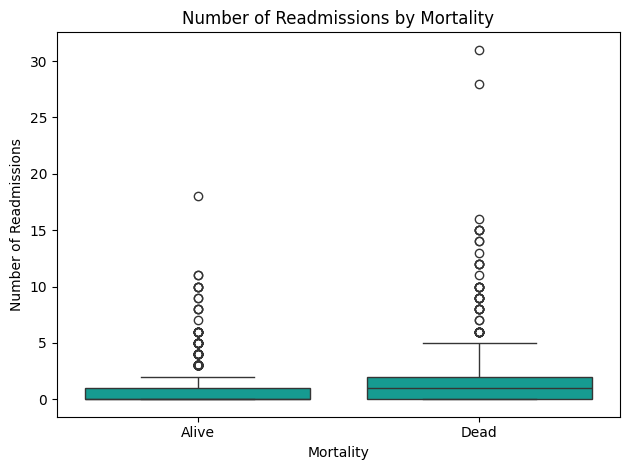

In [ ]:
sns.boxplot(x="mortality_coded", y="number_of_readmissions", data=df, color="#00B1A4")
plt.title("Number of Readmissions by Mortality")
plt.xlabel("Mortality")
plt.ylabel("Number of Readmissions")
plt.tight_layout()
plt.savefig("readmissions_mortality_bp.png", dpi=500, bbox_inches='tight')
plt.show()